<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-07 07:49:52--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  32.9MB/s    in 6.2s    

2026-07-07 07:49:59 (32.5 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


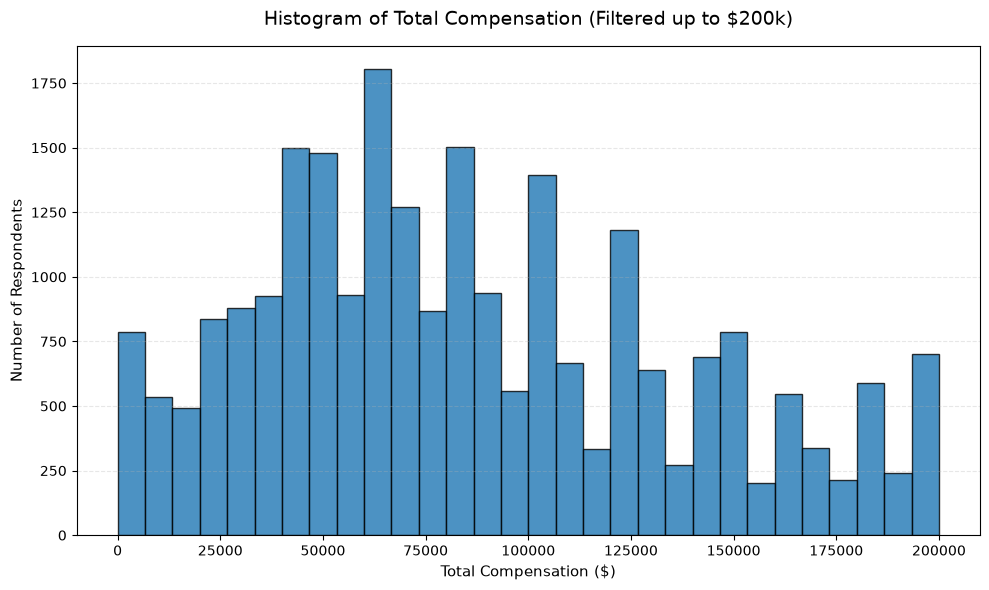

In [9]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read CompTotal
conn = sqlite3.connect("survey-data.sqlite")
df_hist1 = pd.read_sql_query("SELECT CompTotal FROM main", conn)
conn.close()

# 2. Clean data by converting to numeric and dropping missing values
df_hist1['CompTotal'] = pd.to_numeric(df_hist1['CompTotal'], errors='coerce')
df_hist1 = df_hist1.dropna(subset=['CompTotal'])

# 3. Filter out extreme outliers so the histogram distribution is clearly visible
df_filtered = df_hist1[df_hist1['CompTotal'] <= 200000]

# 4. Plot the histogram using pure matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['CompTotal'], bins=30, color='#1f77b4', edgecolor='black', alpha=0.8)

plt.title('Histogram of Total Compensation (Filtered up to $200k)', fontsize=14, pad=15)
plt.xlabel('Total Compensation ($)', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


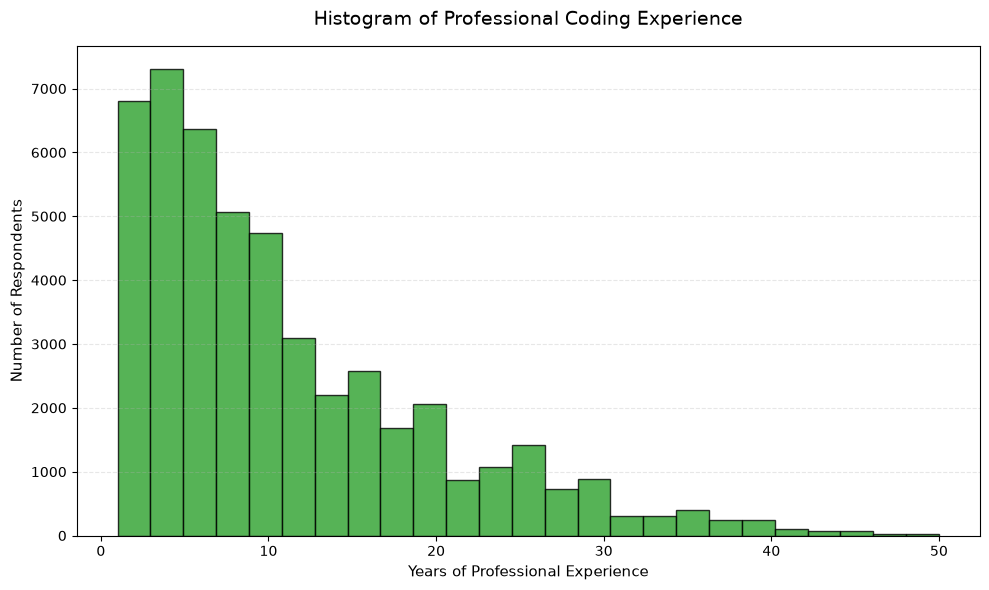

In [10]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read YearsCodePro
conn = sqlite3.connect("survey-data.sqlite")
df_hist2 = pd.read_sql_query("SELECT YearsCodePro FROM main", conn)
conn.close()

# 2. Clean data by converting to numeric and dropping missing rows
df_hist2['YearsCodePro'] = pd.to_numeric(df_hist2['YearsCodePro'], errors='coerce')
df_hist2 = df_hist2.dropna(subset=['YearsCodePro'])

# 3. Plot the histogram using pure matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df_hist2['YearsCodePro'], bins=25, color='#2ca02c', edgecolor='black', alpha=0.8)

plt.title('Histogram of Professional Coding Experience', fontsize=14, pad=15)
plt.xlabel('Years of Professional Experience', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


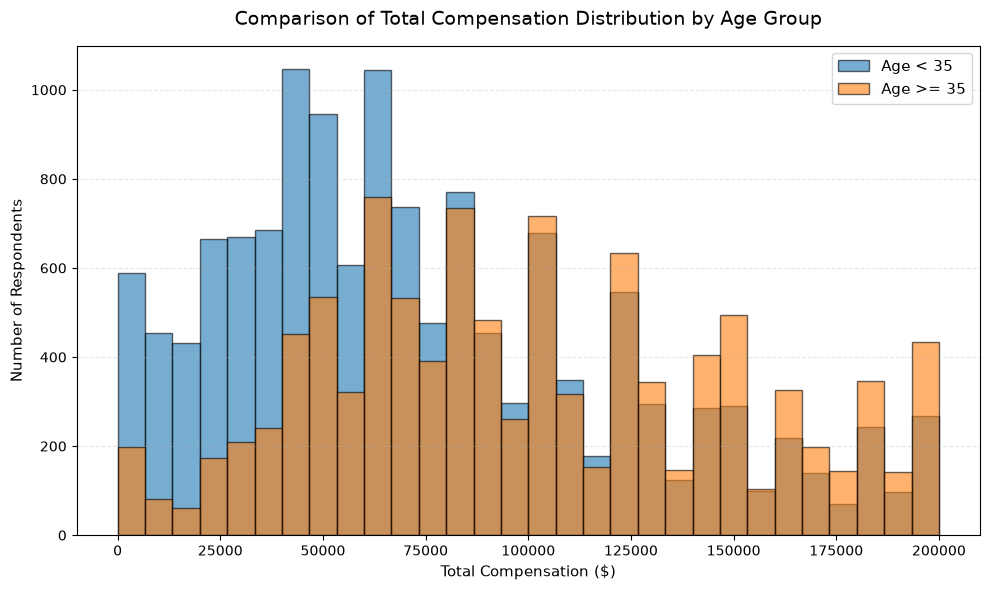

In [11]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read Age and CompTotal cleanly
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(Age AS REAL) AS Age,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
"""
df_comp_age = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop missing rows and filter out extreme salary outliers for better visibility
df_comp_age = df_comp_age.dropna()
df_filtered = df_comp_age[df_comp_age['CompTotal'] <= 200000]

# 3. Create a clean comparison by splitting into two prominent age segments
group_young = df_filtered[df_filtered['Age'] < 35]['CompTotal']
group_mature = df_filtered[df_filtered['Age'] >= 35]['CompTotal']

# 4. Plot overlapping histograms to compare distributions directly
plt.figure(figsize=(10, 6))
plt.hist(group_young, bins=30, alpha=0.6, label='Age < 35', color='#1f77b4', edgecolor='black')
plt.hist(group_mature, bins=30, alpha=0.6, label='Age >= 35', color='#ff7f0e', edgecolor='black')

plt.title('Comparison of Total Compensation Distribution by Age Group', fontsize=14, pad=15)
plt.xlabel('Total Compensation ($)', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


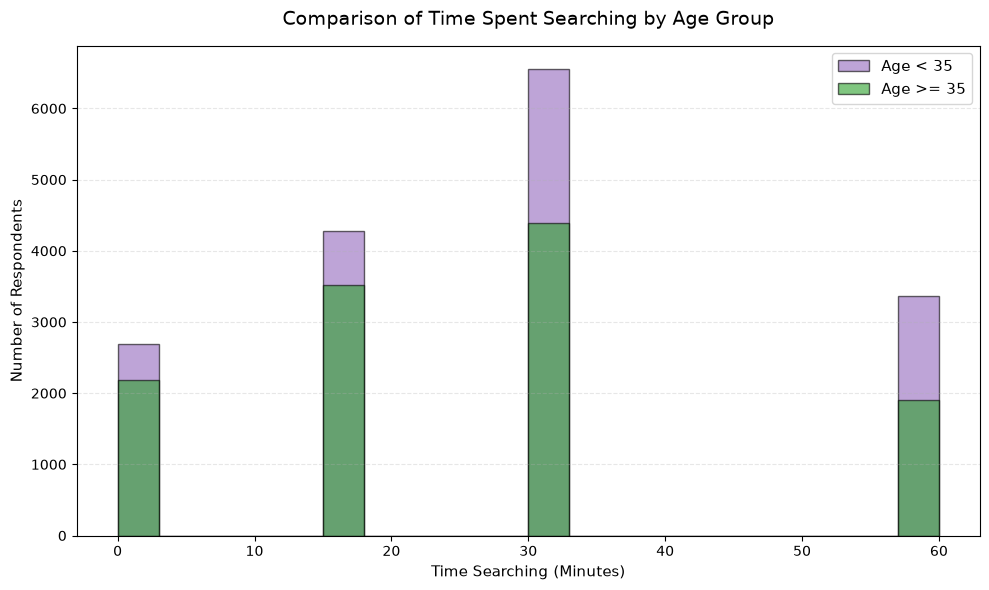

In [12]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read Age and TimeSearching cleanly
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(Age AS REAL) AS Age,
    CAST(TimeSearching AS REAL) AS TimeSearching
FROM main
"""
df_search_age = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop missing rows and clear out extreme search time outliers if any exist
df_search_age = df_search_age.dropna()
df_filtered = df_search_age[df_search_age['TimeSearching'] <= 60] # focuses on up to 60 mins

# 3. Split into the comparison age segments
search_young = df_filtered[df_filtered['Age'] < 35]['TimeSearching']
search_mature = df_filtered[df_filtered['Age'] >= 35]['TimeSearching']

# 4. Plot overlapping histograms
plt.figure(figsize=(10, 6))
plt.hist(search_young, bins=20, alpha=0.6, label='Age < 35', color='#9467bd', edgecolor='black')
plt.hist(search_mature, bins=20, alpha=0.6, label='Age >= 35', color='#2ca02c', edgecolor='black')

plt.title('Comparison of Time Spent Searching by Age Group', fontsize=14, pad=15)
plt.xlabel('Time Searching (Minutes)', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


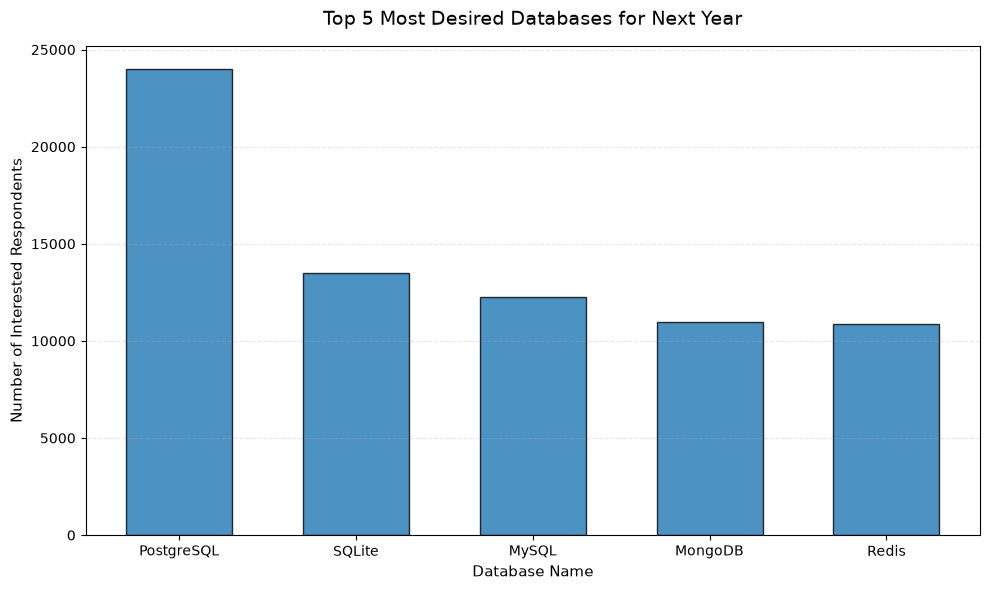

In [13]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read the column
conn = sqlite3.connect("survey-data.sqlite")
df_hist3 = pd.read_sql_query("SELECT DatabaseWantToWorkWith FROM main", conn)
conn.close()

# 2. Drop missing rows, split multiple answers, and explode into individual rows
df_hist3 = df_hist3.dropna(subset=['DatabaseWantToWorkWith'])
all_databases = df_hist3['DatabaseWantToWorkWith'].str.split(';').explode()

# 3. Get the frequencies of the top 5 databases
top5_databases = all_databases.value_counts().head(5)

# 4. Plot the distribution frequency using matplotlib
plt.figure(figsize=(10, 6))
plt.bar(top5_databases.index, top5_databases.values, color='#1f77b4', edgecolor='black', alpha=0.8, width=0.6)

plt.title('Top 5 Most Desired Databases for Next Year', fontsize=14, pad=15)
plt.xlabel('Database Name', fontsize=11)
plt.ylabel('Number of Interested Respondents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


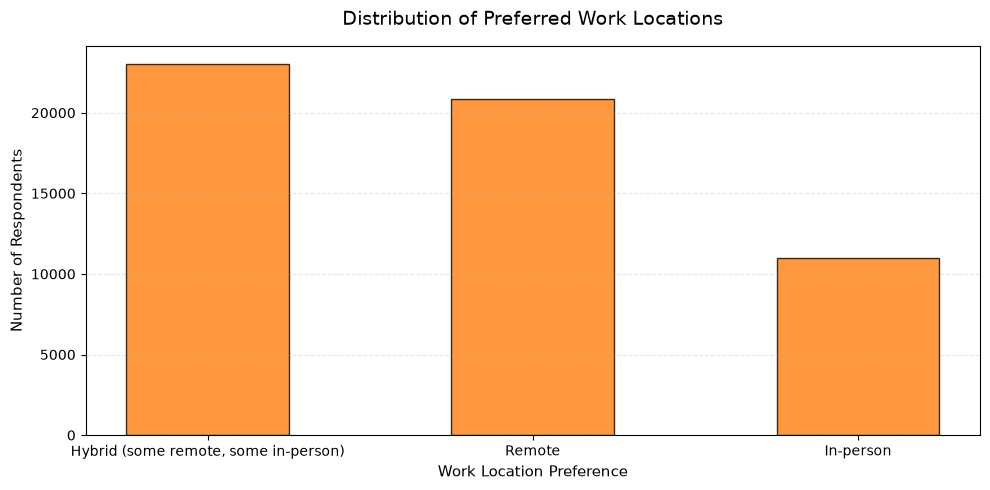

In [14]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read the RemoteWork column
conn = sqlite3.connect("survey-data.sqlite")
df_hist4 = pd.read_sql_query("SELECT RemoteWork FROM main", conn)
conn.close()

# 2. Drop missing rows and get the distribution counts
df_hist4 = df_hist4.dropna(subset=['RemoteWork'])
work_counts = df_hist4['RemoteWork'].value_counts()

# 3. Plot the distribution frequency using matplotlib
plt.figure(figsize=(10, 5))
plt.bar(work_counts.index, work_counts.values, color='#ff7f0e', edgecolor='black', alpha=0.8, width=0.5)

plt.title('Distribution of Preferred Work Locations', fontsize=14, pad=15)
plt.xlabel('Work Location Preference', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


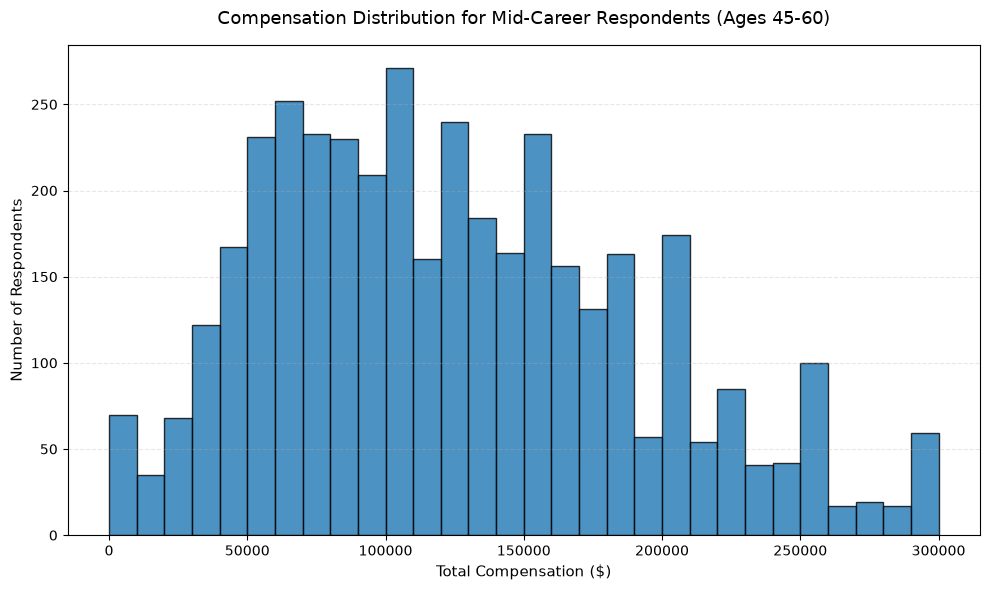

In [15]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query Age and CompTotal using robust casting
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(Age AS REAL) AS Age,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
WHERE CAST(Age AS REAL) BETWEEN 45 AND 60
"""
df_mid_career = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean missing records and filter out massive salary outliers for readability
df_mid_career = df_mid_career.dropna(subset=['CompTotal'])
df_filtered = df_mid_career[df_mid_career['CompTotal'] <= 300000]

# 3. Plot the compensation distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['CompTotal'], bins=30, color='#1f77b4', edgecolor='black', alpha=0.8)

plt.title('Compensation Distribution for Mid-Career Respondents (Ages 45-60)', fontsize=13, pad=15)
plt.xlabel('Total Compensation ($)', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [ ]:
## Write your code here

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
